In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/raw/spy.csv",
    index_col="Date",
    parse_dates=True
)

data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400


In [4]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5535 entries, 2004-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5535 non-null   float64
 1   High    5535 non-null   float64
 2   Low     5535 non-null   float64
 3   Open    5535 non-null   float64
 4   Volume  5535 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 259.5 KB


In [5]:
data.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

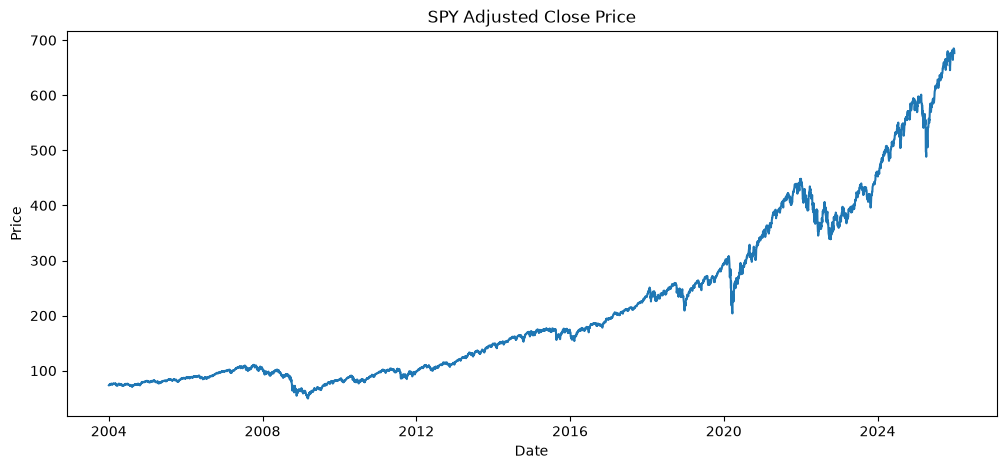

In [6]:
plt.figure(figsize=(12,5))

plt.plot(data.index, data["Close"])

plt.title("SPY Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [7]:
data["return"] = data["Close"].pct_change()

In [8]:
data.head()

,Close,High,Low,Open,Volume,return
Date,,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300,NaN
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800,0.010879
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800,0.000978
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400,0.003376
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400,0.003985


In [9]:
import numpy as np

data["log_return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

In [10]:
data.head()

,Close,High,Low,Open,Volume,return,log_return
Date,,,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300,NaN,NaN
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800,0.010879,0.010820
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800,0.000978,0.000977
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400,0.003376,0.003371
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400,0.003985,0.003977


In [11]:
data["log_return"].describe()

count    5534.000000
mean        0.000401
std         0.011830
min        -0.115886
25%        -0.003939
50%         0.000727
75%         0.005752
max         0.135578
Name: log_return, dtype: float64

In [12]:
daily_vol = data["log_return"].std()

daily_vol

np.float64(0.011830220527261797)

In [13]:
annual_vol = daily_vol * np.sqrt(252)

annual_vol

np.float64(0.18779892882111682)